In [1]:
%pip install -q pandas seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("autoscout24-germany-dataset.csv")
data.head()

,mileage,make,model,fuel,gear,offerType,price,hp,year
0,235000,BMW,316,Diesel,Manual,Used,6800,116.0,2011
1,92800,Volkswagen,Golf,Gasoline,Manual,Used,6877,122.0,2011
2,149300,SEAT,Exeo,Gasoline,Manual,Used,6900,160.0,2011
3,96200,Renault,Megane,Gasoline,Manual,Used,6950,110.0,2011
4,156000,Peugeot,308,Gasoline,Manual,Used,6950,156.0,2011


# Indicar el nombre del dataset, su fuente y el enlace de consulta o descarga. 

In [4]:
nombre_dataset = "Germany Cars Dataset"
fuente = "Kaggle"
enlace = "https://www.kaggle.com/datasets/ander289386/cars-germany"

print("Nombre del dataset:", nombre_dataset)
print("Fuente:", fuente)
print("Enlace de consulta o descarga:", enlace)

Nombre del dataset: Germany Cars Dataset
Fuente: Kaggle
Enlace de consulta o descarga: https://www.kaggle.com/datasets/ander289386/cars-germany


# Presentar una descripción general del dataset. 

In [5]:
# Cantidad filas y columnas
data.shape 

(46405, 9)

In [6]:
# Información del dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 46405 entries, 0 to 46404
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mileage    46405 non-null  int64  
 1   make       46405 non-null  str    
 2   model      46262 non-null  str    
 3   fuel       46405 non-null  str    
 4   gear       46223 non-null  str    
 5   offerType  46405 non-null  str    
 6   price      46405 non-null  int64  
 7   hp         46376 non-null  float64
 8   year       46405 non-null  int64  
dtypes: float64(1), int64(3), str(5)
memory usage: 4.6 MB


In [7]:
# Trae 10 filas aleatorias del dataset
data.sample(10)

,mileage,make,model,fuel,gear,offerType,price,hp,year
14592,180000,Volkswagen,Passat Variant,Diesel,Manual,Used,6490,105.0,2012
4483,72000,Fiat,500C,Gasoline,Manual,Used,6499,69.0,2013
7571,16652,Audi,Q3,Gasoline,Automatic,Used,39980,230.0,2020
37349,218761,Volkswagen,Passat Variant,Diesel,Automatic,Used,8900,140.0,2013
29460,108600,SEAT,Mii,Gasoline,Manual,Used,4490,60.0,2015
32597,96879,Peugeot,207,Gasoline,Manual,Used,3800,73.0,2011
21372,80210,Mercedes-Benz,B 180,Gasoline,Automatic,Used,12999,122.0,2012
24672,119450,BMW,530,Gasoline,Automatic,Used,26749,252.0,2017
42320,30000,MINI,One,Gasoline,Manual,Used,13000,102.0,2018
42163,47000,Mitsubishi,Space Star,Gasoline,Manual,Used,7150,80.0,2018


In [8]:
# Reinicia el índice del dataset
data = data.reset_index(drop=True)

# Agrega un ID único y consecutivo para identificar cada vehículo
data.insert(0, "id", range(1, len(data) + 1))

In [9]:
data.set_index('id', inplace=True)

In [10]:
data.head()

,mileage,make,model,fuel,gear,offerType,price,hp,year
id,,,,,,,,,
1,235000,BMW,316,Diesel,Manual,Used,6800,116.0,2011
2,92800,Volkswagen,Golf,Gasoline,Manual,Used,6877,122.0,2011
3,149300,SEAT,Exeo,Gasoline,Manual,Used,6900,160.0,2011
4,96200,Renault,Megane,Gasoline,Manual,Used,6950,110.0,2011
5,156000,Peugeot,308,Gasoline,Manual,Used,6950,156.0,2011


In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 46405 entries, 1 to 46405
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mileage    46405 non-null  int64  
 1   make       46405 non-null  str    
 2   model      46262 non-null  str    
 3   fuel       46405 non-null  str    
 4   gear       46223 non-null  str    
 5   offerType  46405 non-null  str    
 6   price      46405 non-null  int64  
 7   hp         46376 non-null  float64
 8   year       46405 non-null  int64  
dtypes: float64(1), int64(3), str(5)
memory usage: 4.6 MB


In [12]:
columns_date = []

columns_categorical = [
    'make',
    'model',
    'fuel',
    'gear',
    'offerType'
]

columns_numerical = [
    'mileage',
    'price',
    'hp',
    'year'
]

len(columns_date) + len(columns_categorical) + len(columns_numerical) == data.shape[1]

True

In [13]:
# Muestra la cantidad de veces que se repite cada valor en la columna 'id'.
data.index.value_counts()

id
1        1
2        1
3        1
4        1
5        1
        ..
46401    1
46402    1
46403    1
46404    1
46405    1
Name: count, Length: 46405, dtype: int64

In [14]:
for col_categorical in columns_categorical:
    data[col_categorical] = data[col_categorical].astype('category')

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 46405 entries, 1 to 46405
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   mileage    46405 non-null  int64   
 1   make       46405 non-null  category
 2   model      46262 non-null  category
 3   fuel       46405 non-null  category
 4   gear       46223 non-null  category
 5   offerType  46405 non-null  category
 6   price      46405 non-null  int64   
 7   hp         46376 non-null  float64 
 8   year       46405 non-null  int64   
dtypes: category(5), float64(1), int64(3)
memory usage: 1.7 MB


In [15]:
data.dtypes

mileage         int64
make         category
model        category
fuel         category
gear         category
offerType    category
price           int64
hp            float64
year            int64
dtype: object

# Análisis Univariante

## Categórico

In [16]:
data["make"].value_counts()

make
Volkswagen    6931
Opel          4814
Ford          4442
Skoda         2889
Renault       2830
              ... 
FISKER           1
Isuzu            1
Tazzari          1
Trucks-Lkw       1
Zhidou           1
Name: count, Length: 77, dtype: int64

In [17]:
data["model"].value_counts()

model
Golf                      1492
Corsa                     1491
Fiesta                    1289
Astra                     1191
Focus                      985
                          ... 
Z4 M                         1
city-coupé/city-cabrio       1
e                            1
e-Niro                       1
iX3                          1
Name: count, Length: 841, dtype: int64

In [18]:
data["fuel"].value_counts()

fuel
Gasoline             28864
Diesel               15244
Electric/Gasoline     1158
Electric               758
LPG                    126
CNG                    117
Others                  56
Electric/Diesel         53
-/- (Fuel)              26
Ethanol                  2
Hydrogen                 1
Name: count, dtype: int64

In [19]:
data["gear"].value_counts()

gear
Manual            30380
Automatic         15787
Semi-automatic       56
Name: count, dtype: int64

In [20]:
data["offerType"].value_counts()

offerType
Used              40122
Pre-registered     2780
Demonstration      2368
Employee's car     1122
New                  13
Name: count, dtype: int64


ANÁLISIS DE: MAKE

Cantidad de categorías: 77

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,Volkswagen,6931,14.94
1,Opel,4814,10.37
2,Ford,4442,9.57
3,Skoda,2889,6.23
4,Renault,2830,6.10
...,...,...,...
72,FISKER,1,0.00
73,Isuzu,1,0.00
74,Tazzari,1,0.00
75,Trucks-Lkw,1,0.00



Nota: make tiene 77 categorías (≥15), no se generó gráfico.

ANÁLISIS DE: MODEL

Cantidad de categorías: 841

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,Golf,1492,3.22
1,Corsa,1491,3.21
2,Fiesta,1289,2.78
3,Astra,1191,2.57
4,Focus,985,2.12
...,...,...,...
836,Z4 M,1,0.00
837,city-coupé/city-cabrio,1,0.00
838,e,1,0.00
839,e-Niro,1,0.00



Nota: model tiene 841 categorías (≥15), no se generó gráfico.

ANÁLISIS DE: FUEL

Cantidad de categorías: 11

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,Gasoline,28864,62.20
1,Diesel,15244,32.85
2,Electric/Gasoline,1158,2.50
3,Electric,758,1.63
4,LPG,126,0.27
5,CNG,117,0.25
6,Others,56,0.12
7,Electric/Diesel,53,0.11
8,-/- (Fuel),26,0.06
9,Ethanol,2,0.00


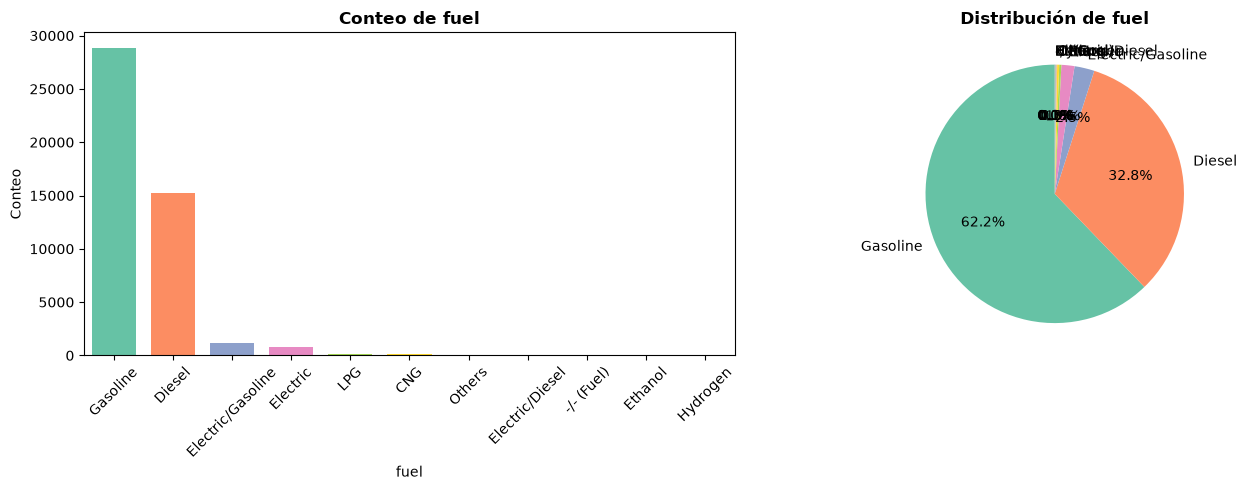


ANÁLISIS DE: GEAR

Cantidad de categorías: 3

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,Manual,30380,65.47
1,Automatic,15787,34.02
2,Semi-automatic,56,0.12


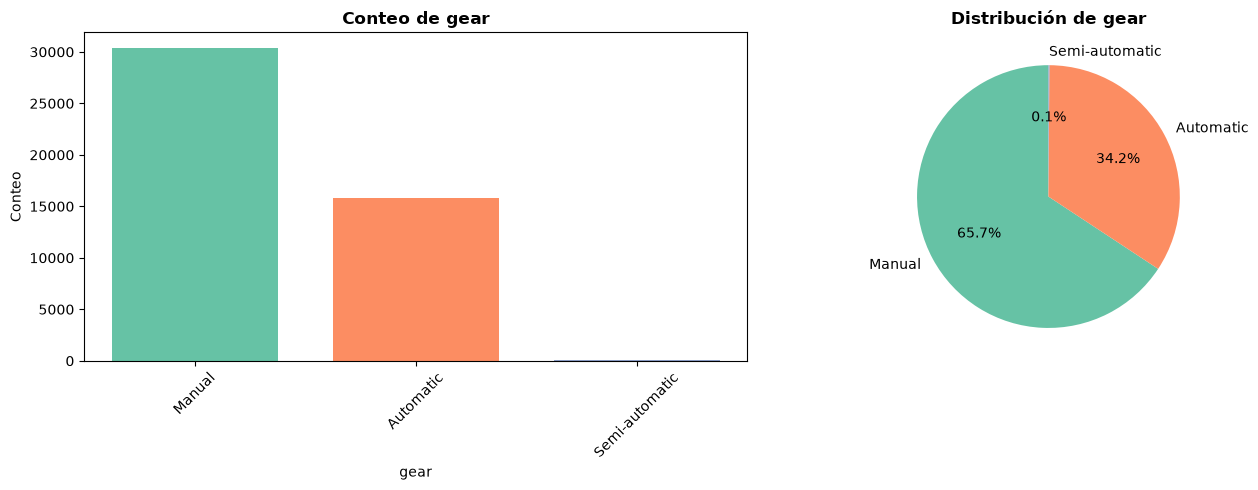


ANÁLISIS DE: OFFERTYPE

Cantidad de categorías: 5

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,Used,40122,86.46
1,Pre-registered,2780,5.99
2,Demonstration,2368,5.10
3,Employee's car,1122,2.42
4,New,13,0.03


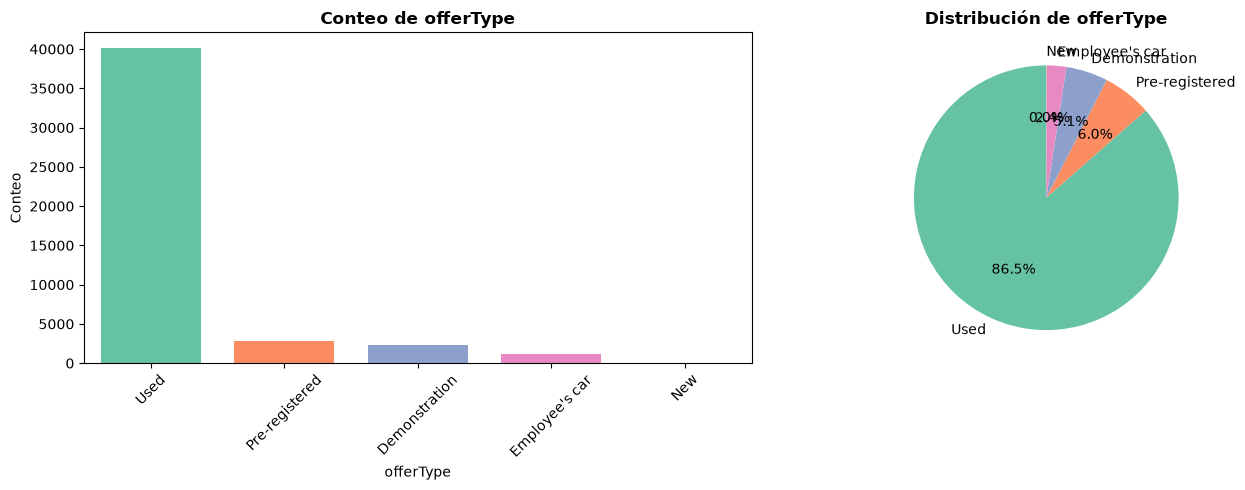

In [21]:
for col in columns_categorical:
    print(f"\n{'='*70}")
    print(f"ANÁLISIS DE: {col.upper()}")
    print(f"{'='*70}")
    
    # 1. Cantidad de categorías
    num_categories = data[col].nunique()
    print(f"\nCantidad de categorías: {num_categories}")
    
    # 2. Tabla de conteo y porcentajes
    value_counts = data[col].value_counts()
    percentage = (value_counts / len(data) * 100).round(2)
    
    table = pd.DataFrame({
        'Categoría': value_counts.index,
        'Conteo': value_counts.values,
        'Porcentaje (%)': percentage.values
    })
    print("\nTabla de conteo y porcentajes:")
    display(table)
    
    # 3. Gráfico si tiene menos de 10 categorías
    if num_categories < 15:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Crear mapeo de colores consistente
        colors_array = plt.cm.Set2(range(num_categories))
        
        # Gráfico de barras a la izquierda
        sns.countplot(data=data, x=col, ax=axes[0], 
                      order=data[col].value_counts().index, legend=False, width=0.75)
        
        # Aplicar colores manualmente a las barras para que coincidan con el pie chart
        for i, patch in enumerate(axes[0].patches):
            patch.set_facecolor(colors_array[i])
        
        axes[0].set_title(f'Conteo de {col}', fontsize=12, fontweight='bold')
        axes[0].set_xlabel(col, fontsize=10)
        axes[0].set_ylabel('Conteo', fontsize=10)
        axes[0].tick_params(axis='x', rotation=45)
        
        # Gráfico de torta a la derecha
        axes[1].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%', 
                    startangle=90, colors=colors_array)
        axes[1].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nNota: {col} tiene {num_categories} categorías (≥15), no se generó gráfico.")

## Numérico


ANÁLISIS DE: MILEAGE

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
mileage,46405.0,71177.864109,62625.308456,0.0,19800.0,60000.0,105000.0,1111111.0


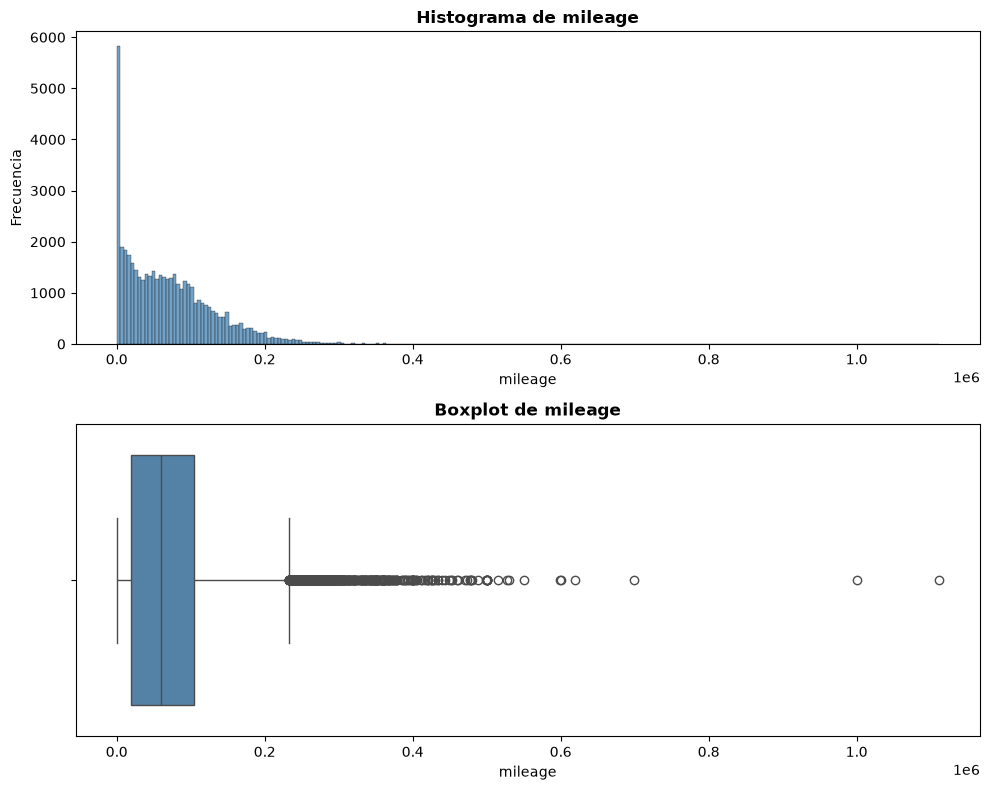


ANÁLISIS DE: PRICE

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
price,46405.0,16572.337227,19304.695924,1100.0,7490.0,10999.0,19490.0,1199900.0


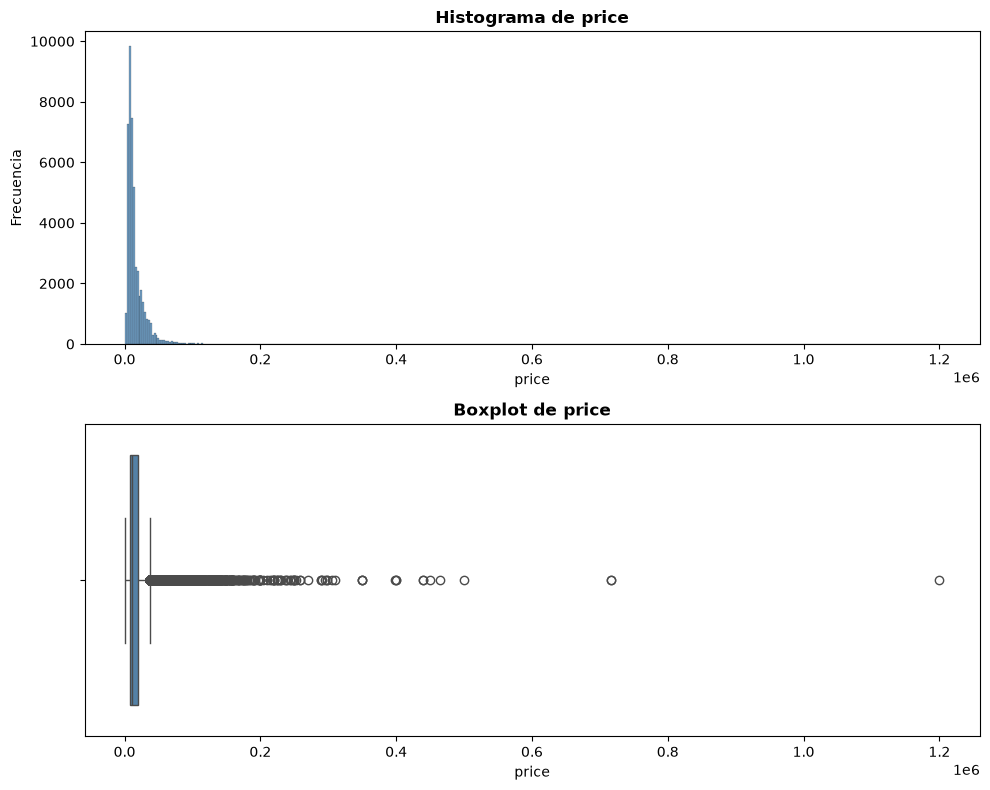


ANÁLISIS DE: HP

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
hp,46376.0,132.990987,75.449284,1.0,86.0,116.0,150.0,850.0


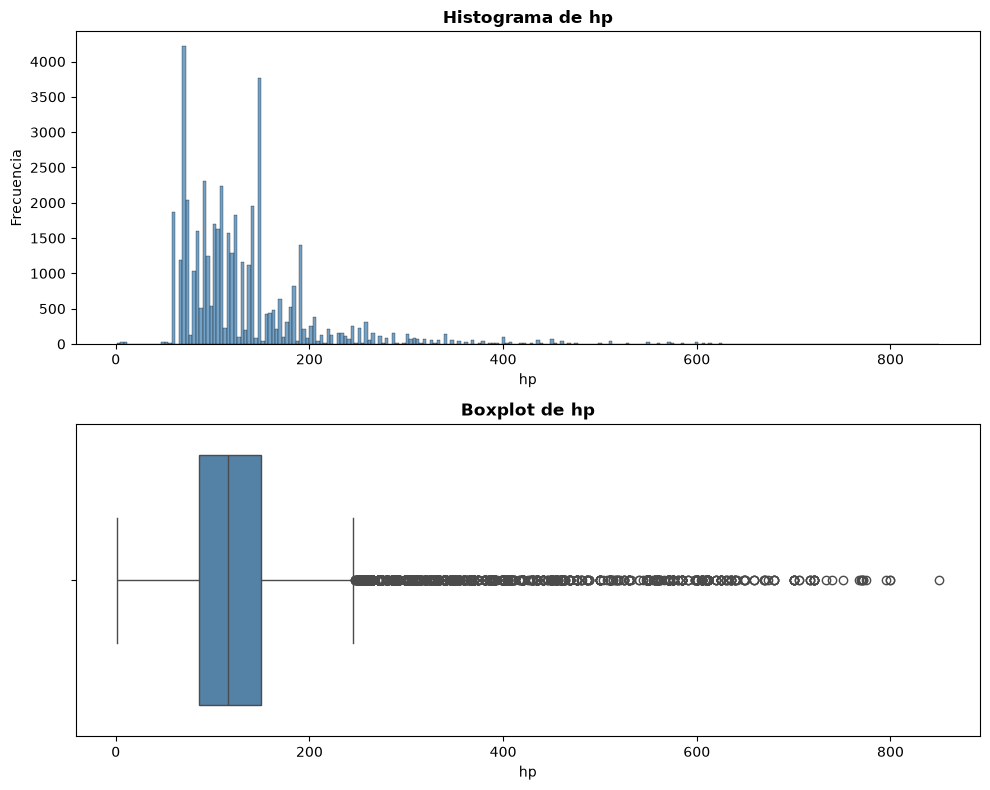


ANÁLISIS DE: YEAR

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
year,46405.0,2016.012951,3.155214,2011.0,2013.0,2016.0,2019.0,2021.0


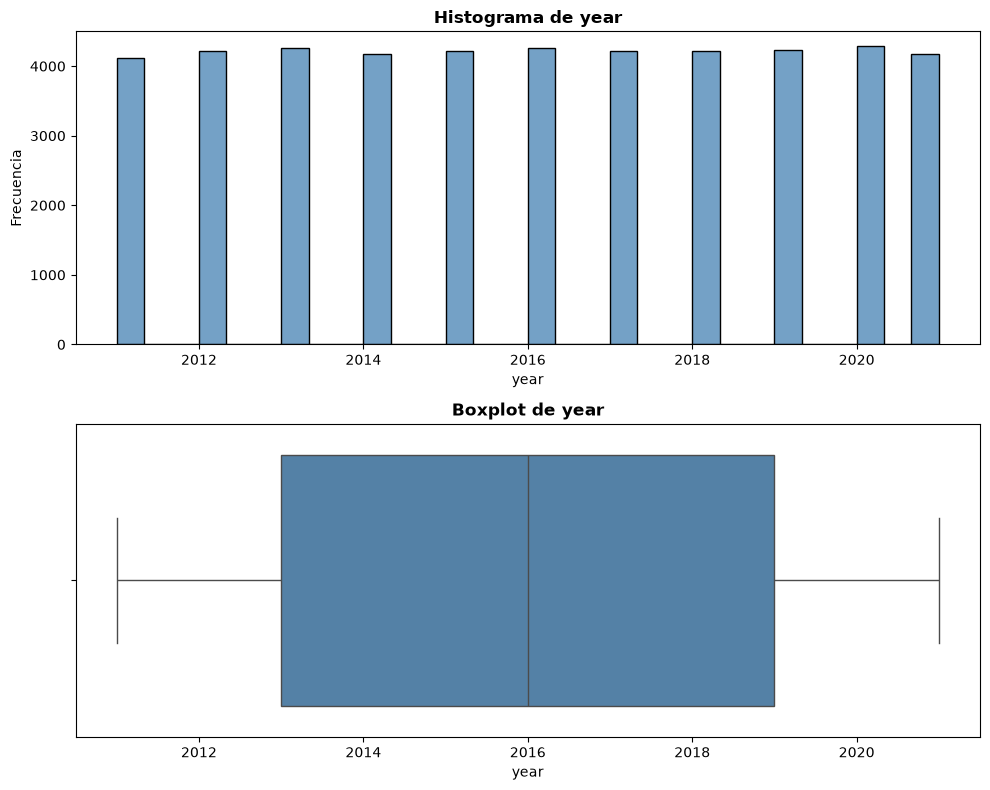

In [22]:
for col in columns_numerical:
    print(f"\n{'='*70}")
    print(f"ANÁLISIS DE: {col.upper()}")
    print(f"{'='*70}")
    
    # Tabla de estadística descriptiva
    stats = data[col].describe().to_frame().T
    print("\nEstadística descriptiva:")
    display(stats)
    
    # Subplots: histograma arriba, boxplot abajo
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))
    
    sns.histplot(data=data, x=col, ax=axes[0], color='steelblue')
    axes[0].set_title(f'Histograma de {col}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(col, fontsize=10)
    axes[0].set_ylabel('Frecuencia', fontsize=10)
    
    sns.boxplot(data=data, x=col, ax=axes[1], color='steelblue')
    axes[1].set_title(f'Boxplot de {col}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(col, fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Análisis bivariante

## Numérico

In [23]:
data[columns_numerical].corr()

,mileage,price,hp,year
mileage,1.000000,-0.302788,-0.015086,-0.676131
price,-0.302788,1.000000,0.747617,0.405633
hp,-0.015086,0.747617,1.000000,0.167232
year,-0.676131,0.405633,0.167232,1.000000


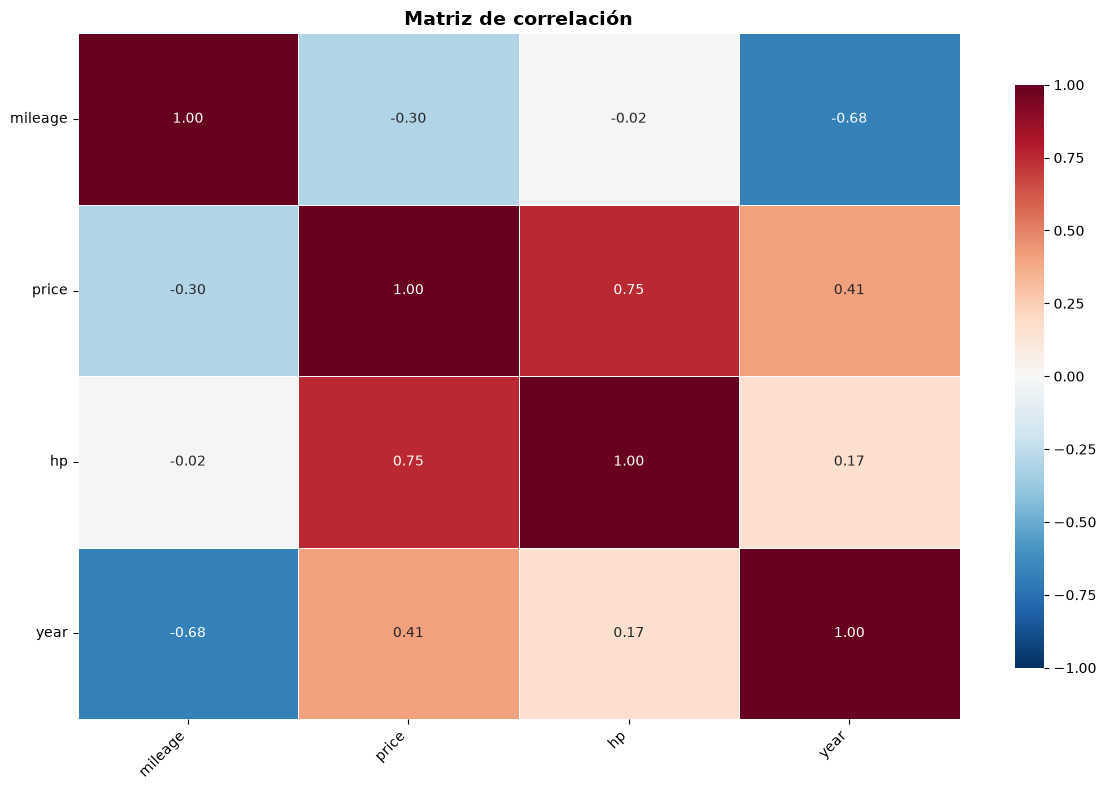

In [24]:
corr_matrix = data[columns_numerical].corr().round(2)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.85}
)
plt.title('Matriz de correlación', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

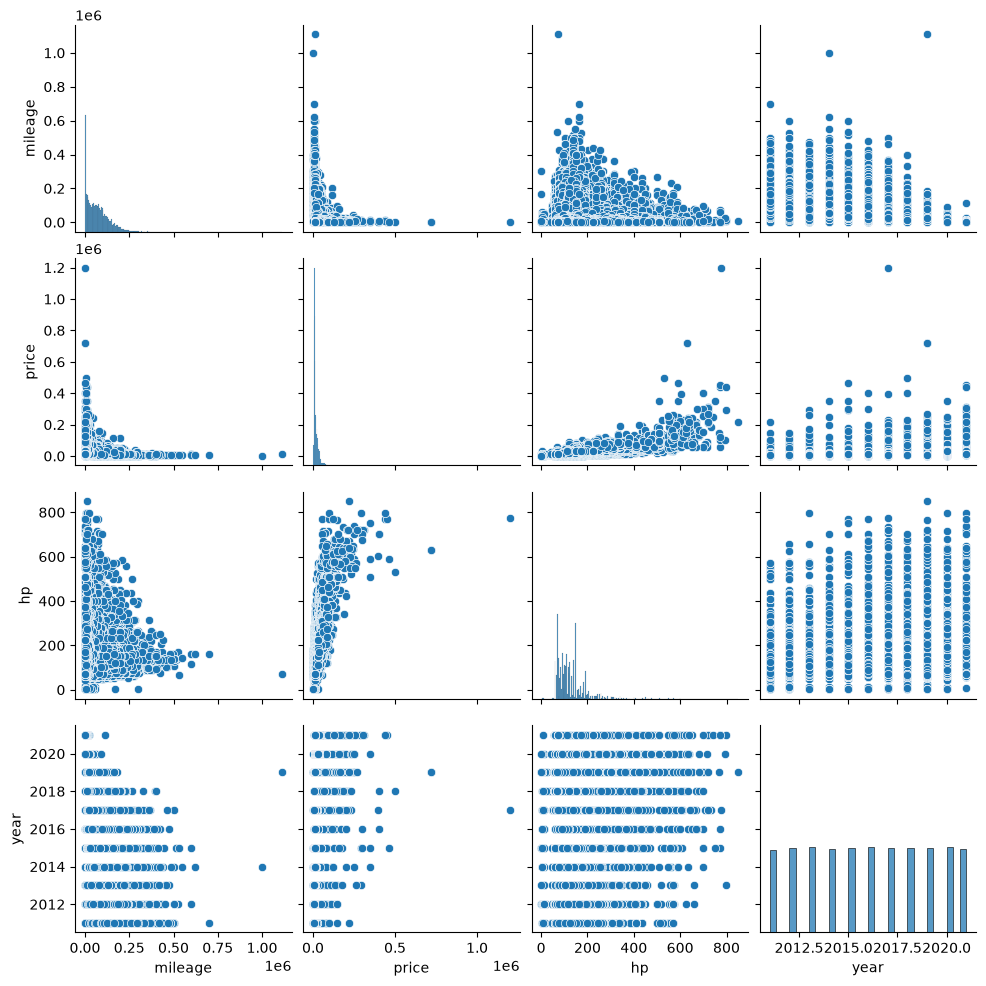

In [25]:
plt.figure(figsize=(10, 8))
sns.pairplot(data[columns_numerical])
plt.show()

## Categórico

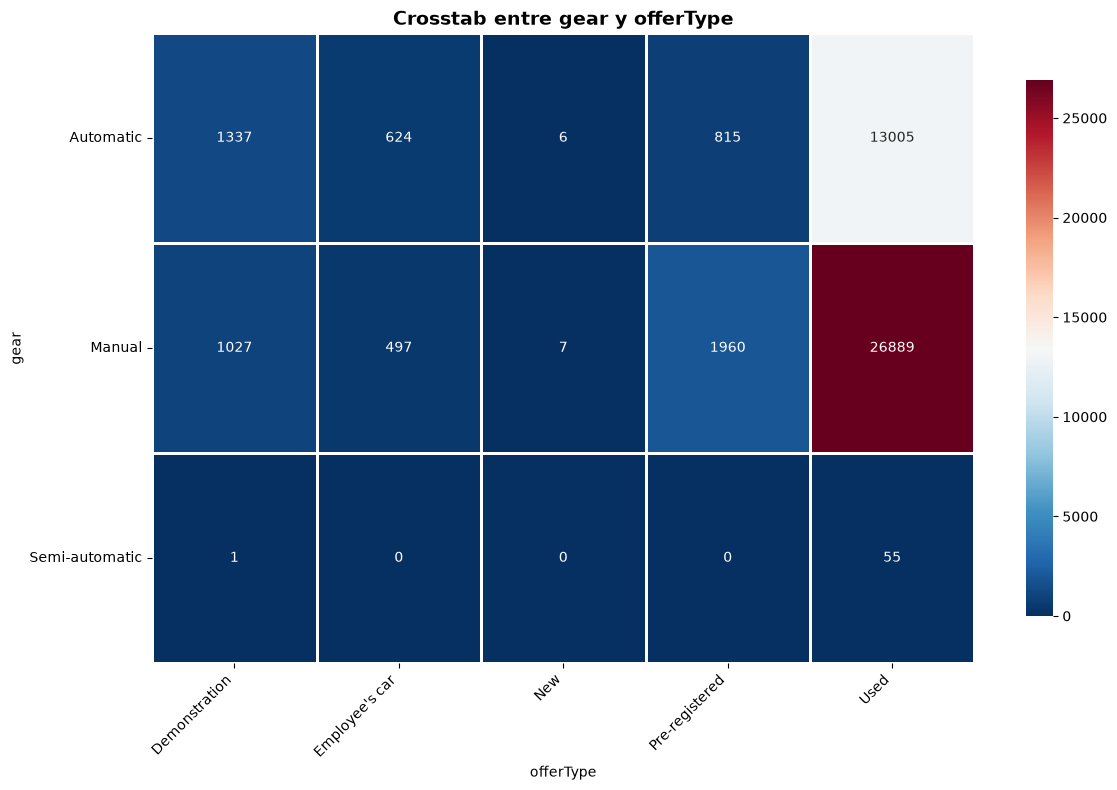

In [26]:
# Define aquí las dos columnas que quieres cruzar
columna_filas = 'gear'
columna_columnas = 'offerType'

# Crosstab con conteos absolutos
crosstab = pd.crosstab(
    data[columna_filas],
    data[columna_columnas]
).astype(int)

valor_min = crosstab.values.min()
valor_max = crosstab.values.max()

plt.figure(figsize=(12, 8))
sns.heatmap(
    crosstab,
    annot=True,
    fmt='d',
    cmap='RdBu_r',
    vmin=valor_min,
    vmax=valor_max,
    linewidths=2,
    linecolor='white',
    cbar_kws={'shrink': 0.85}
)
plt.title(f'Crosstab entre {columna_filas} y {columna_columnas}', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

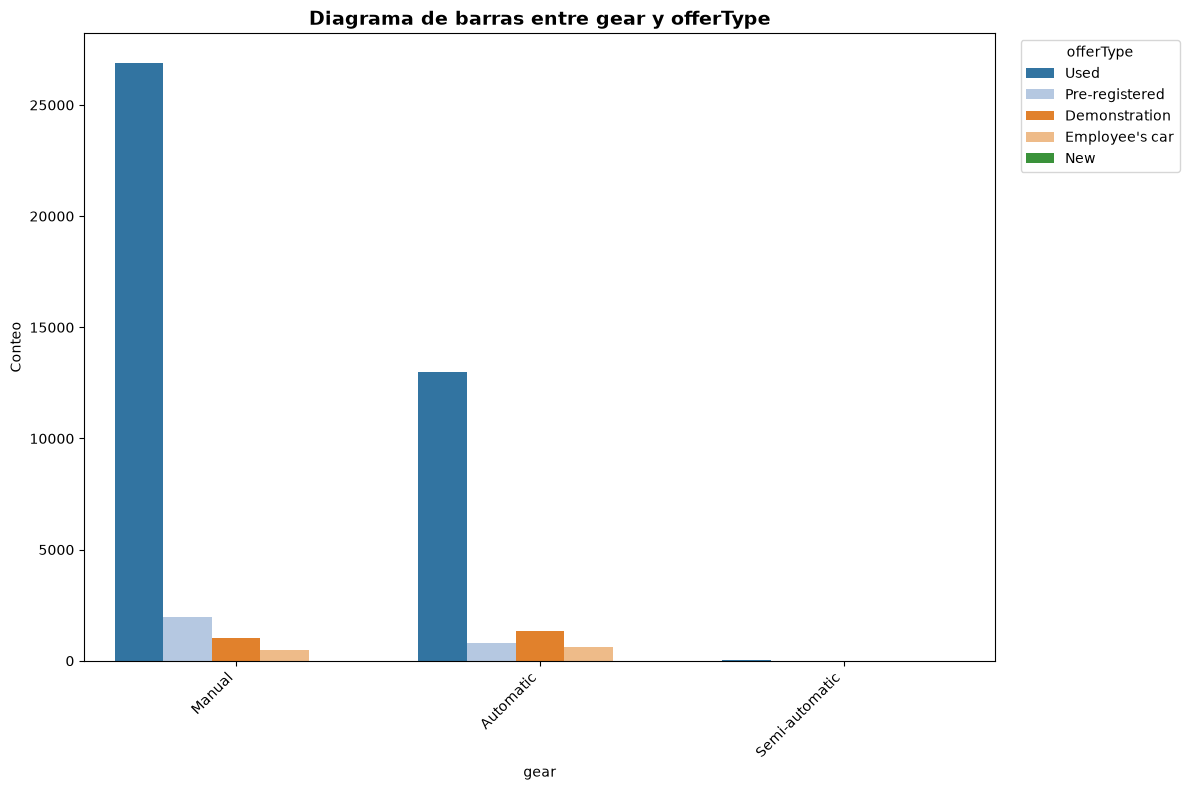

In [27]:
# Define aquí las dos columnas que quieres cruzar
columna_filas = 'gear'
columna_columnas = 'offerType'

plt.figure(figsize=(12, 8))
sns.countplot(
    data=data,
    x=columna_filas,
    hue=columna_columnas,
    order=data[columna_filas].value_counts().index,
    hue_order=data[columna_columnas].value_counts().index,
    palette='tab20'
)
plt.title(f'Diagrama de barras entre {columna_filas} y {columna_columnas}', fontsize=14, fontweight='bold')
plt.xlabel(columna_filas, fontsize=10)
plt.ylabel('Conteo', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.legend(title=columna_columnas, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Numérico + Categórico

Variable categórica: gear
Variable numérica: hp


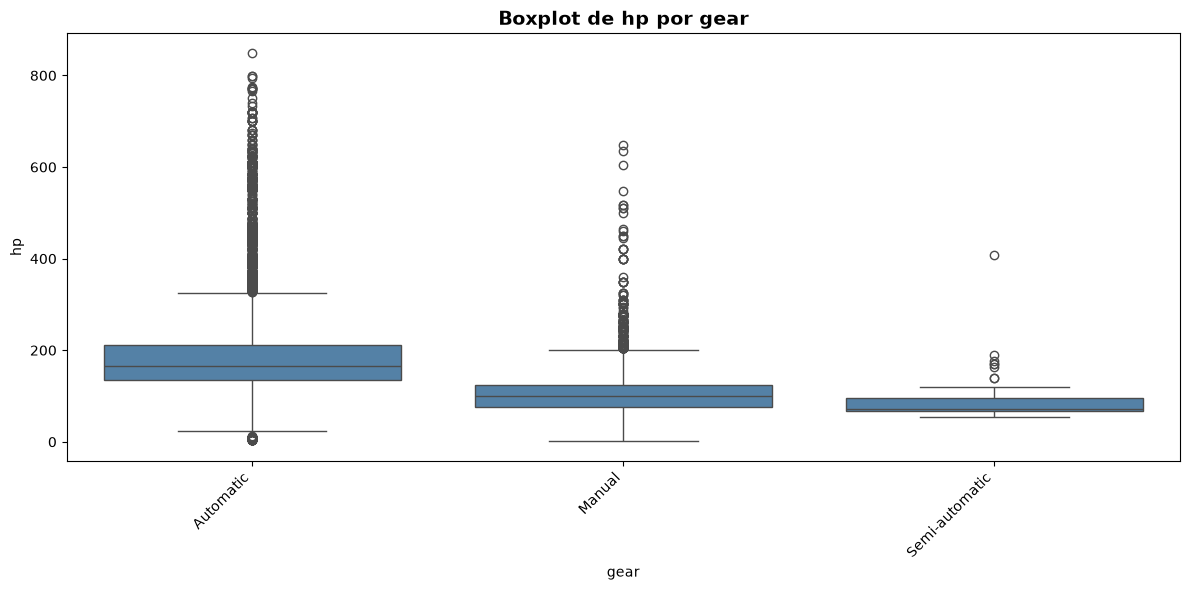

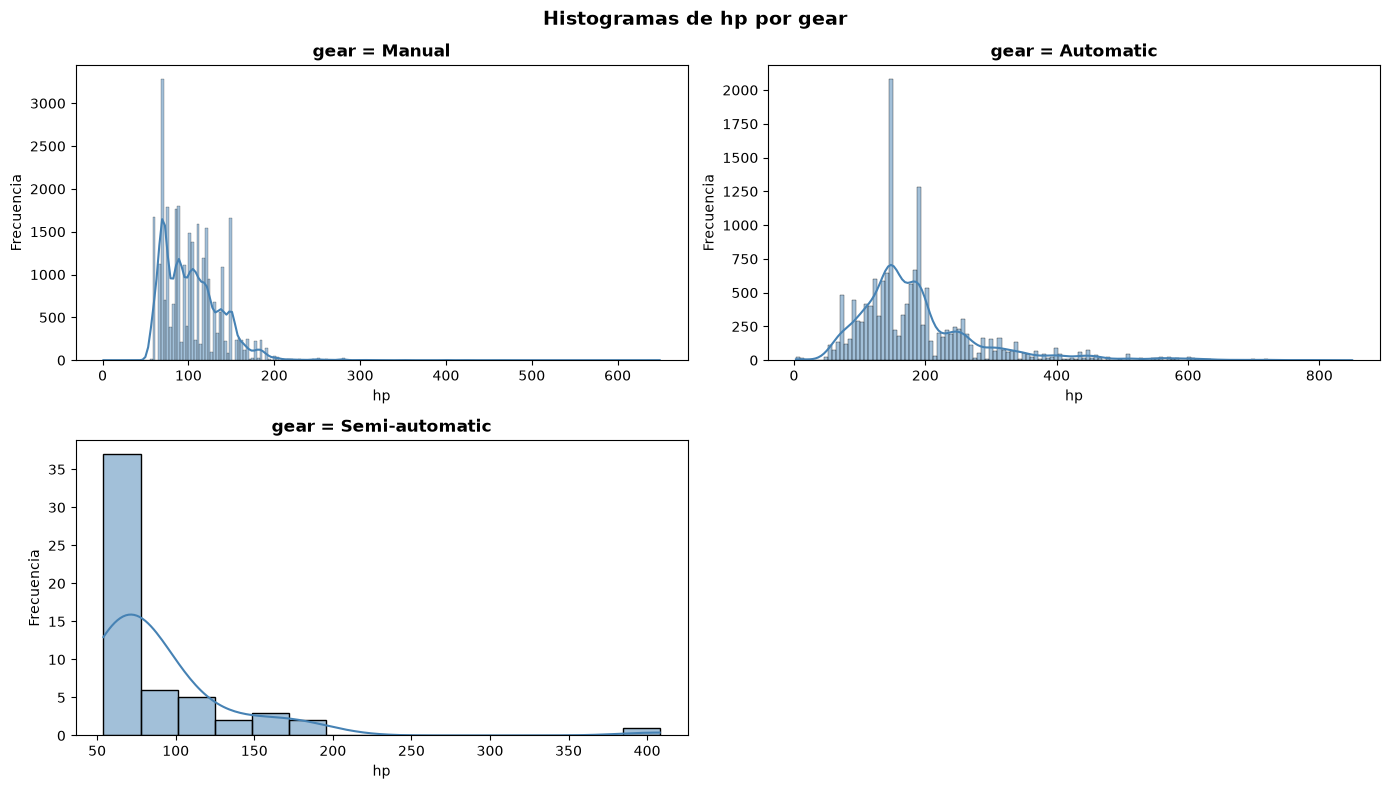

In [28]:
# Define aquí una variable categórica y una numérica
columna_categorica = 'gear'
columna_numerica = 'hp'

print(f'Variable categórica: {columna_categorica}')
print(f'Variable numérica: {columna_numerica}')

# Boxplot comparativo por categoría
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=data,
    x=columna_categorica,
    y=columna_numerica,
    color='steelblue'
)
plt.title(f'Boxplot de {columna_numerica} por {columna_categorica}', fontsize=14, fontweight='bold')
plt.xlabel(columna_categorica, fontsize=10)
plt.ylabel(columna_numerica, fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Histogramas en subplots separados por categoría
categorias = data[columna_categorica].dropna().unique()
num_categorias = len(categorias)
num_columnas = 2
num_filas = (num_categorias + num_columnas - 1) // num_columnas

fig, axes = plt.subplots(num_filas, num_columnas, figsize=(14, 4 * num_filas))
axes = axes.flatten() if num_categorias > 1 else [axes]

for i, categoria in enumerate(categorias):
    subset = data[data[columna_categorica] == categoria]
    sns.histplot(
        data=subset,
        x=columna_numerica,
        kde=True,
        color='steelblue',
        ax=axes[i]
    )
    axes[i].set_title(f'{columna_categorica} = {categoria}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(columna_numerica, fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=10)

for j in range(num_categorias, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'Histogramas de {columna_numerica} por {columna_categorica}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Preguntas interesantes que puedan responderse con los datos seleccionados

## 1. ¿Cuál es la marca de vehículo que más aparece en el dataset?

Marca que más aparece: Volkswagen
Cantidad de vehículos: 6931


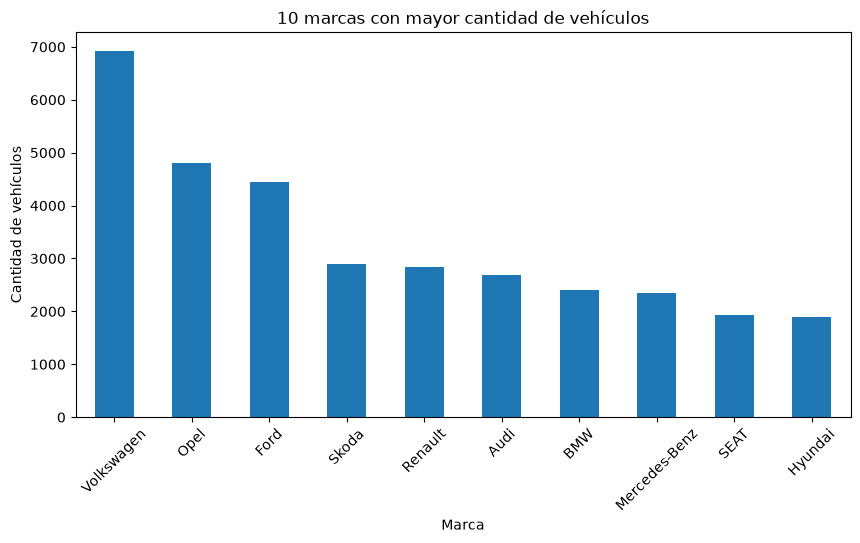

Conclusión: La marca que más aparece en el dataset es Volkswagen, con 6931 vehículos.


In [29]:
# Contar la cantidad de vehículos por marca
cantidad_marcas = data['make'].value_counts()

# Obtener la marca más frecuente
marca_mas_comun = cantidad_marcas.idxmax()
cantidad = cantidad_marcas.max()

print("Marca que más aparece:", marca_mas_comun)
print("Cantidad de vehículos:", cantidad)

# Visualización de las 10 marcas más frecuentes
cantidad_marcas.head(10).plot(
    kind='bar',
    figsize=(10, 5),
    title='10 marcas con mayor cantidad de vehículos'
)

plt.xlabel('Marca')
plt.ylabel('Cantidad de vehículos')
plt.xticks(rotation=45)
plt.show()

print(f"Conclusión: La marca que más aparece en el dataset es {marca_mas_comun}, con {cantidad} vehículos.")

## 2. ¿Cuál es el vehículo más caro del dataset?

In [30]:
# Encontrar el precio máximo
precio_maximo = data['price'].max()

# Mostrar el vehículo o vehículos con ese precio
vehiculo_mas_caro = data[data['price'] == precio_maximo][
    ['make', 'model', 'year', 'mileage', 'price']
]

display(vehiculo_mas_caro)

print(f"Conclusión: El precio máximo encontrado en el dataset es {precio_maximo}.")

,make,model,year,mileage,price
id,,,,,
21676,Ferrari,F12,2017,431,1199900


Conclusión: El precio máximo encontrado en el dataset es 1199900.


## 3. ¿Qué tipo de combustible es el más común?

Combustible más común: Gasoline
Cantidad de vehículos: 28864


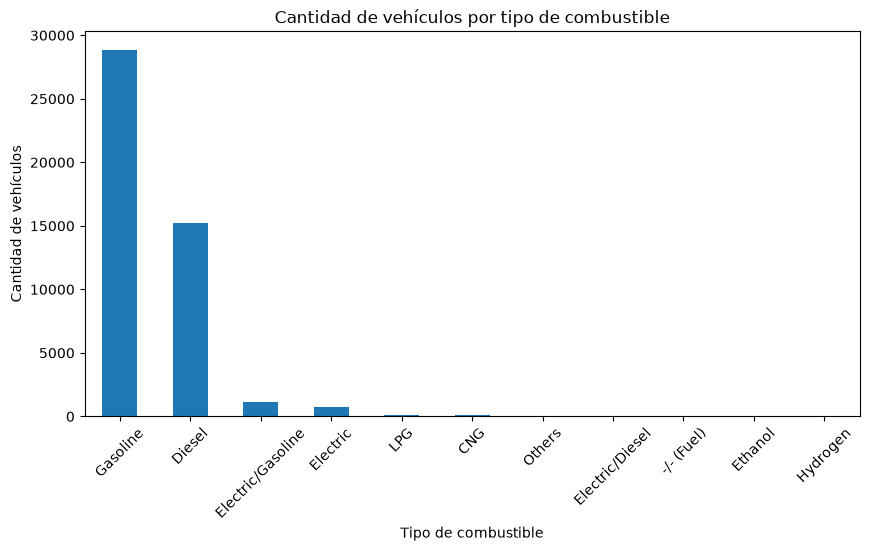

Conclusión: El tipo de combustible más común es Gasoline, con 28864 vehículos.


In [31]:
# Contar los vehículos según el tipo de combustible
cantidad_combustible = data['fuel'].value_counts()

combustible_mas_comun = cantidad_combustible.idxmax()
cantidad = cantidad_combustible.max()

print("Combustible más común:", combustible_mas_comun)
print("Cantidad de vehículos:", cantidad)

# Gráfico
cantidad_combustible.plot(
    kind='bar',
    figsize=(10, 5),
    title='Cantidad de vehículos por tipo de combustible'
)

plt.xlabel('Tipo de combustible')
plt.ylabel('Cantidad de vehículos')
plt.xticks(rotation=45)
plt.show()

print(
    f"Conclusión: El tipo de combustible más común es "
    f"{combustible_mas_comun}, con {cantidad} vehículos."
)

## 4. ¿Los vehículos automáticos o manuales tienen un precio promedio más alto?

gear
Automatic         28216.003737
Manual            10569.031666
Semi-automatic     8424.982143
Name: price, dtype: float64

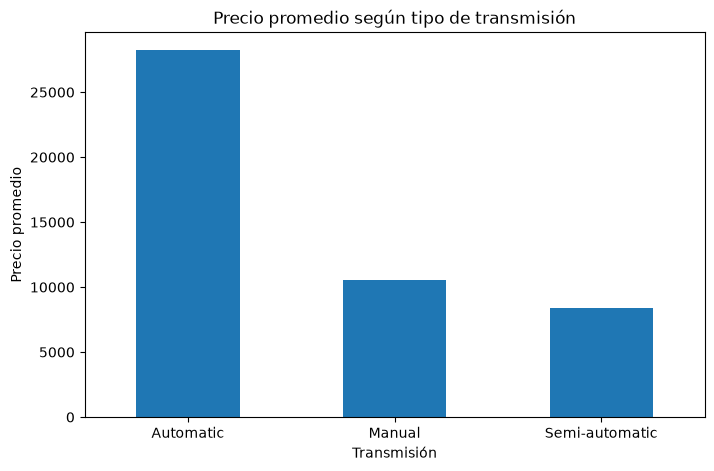

Conclusión: Los vehículos con transmisión Automatic presentan el mayor precio promedio, con 28216.00.


In [32]:
# Calcular precio promedio según el tipo de transmisión
precio_transmision = (
    data.groupby('gear')['price']
    .mean()
    .sort_values(ascending=False)
)

display(precio_transmision)

# Identificar la transmisión con mayor precio promedio
transmision_mayor = precio_transmision.idxmax()
precio_promedio_mayor = precio_transmision.max()

# Gráfico
precio_transmision.plot(
    kind='bar',
    figsize=(8, 5),
    title='Precio promedio según tipo de transmisión'
)

plt.xlabel('Transmisión')
plt.ylabel('Precio promedio')
plt.xticks(rotation=0)
plt.show()

print(
    f"Conclusión: Los vehículos con transmisión {transmision_mayor} "
    f"presentan el mayor precio promedio, con {precio_promedio_mayor:.2f}."
)

## 5. ¿Qué marca tiene, en promedio, los vehículos con mayor potencia?

make
Ferrari        693.909091
Lamborghini    690.111111
Corvette       687.000000
McLaren        646.636364
Rolls-Royce    605.000000
Bentley        554.866667
Maybach        543.000000
Aston          531.833333
Tesla          494.416667
Alpina         443.000000
Name: hp, dtype: float64

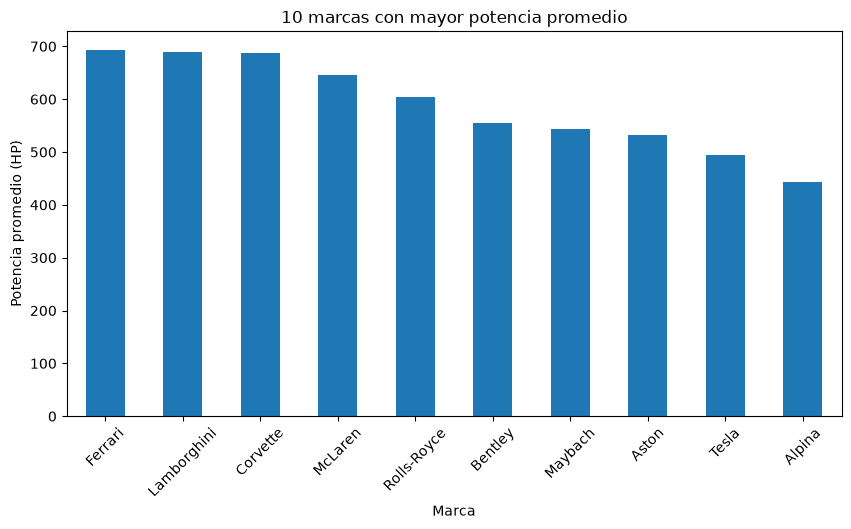

Conclusión: La marca con mayor potencia promedio es Ferrari, con 693.91 HP.


In [33]:
# Eliminar temporalmente registros sin información de potencia
data_hp = data.dropna(subset=['hp'])

# Calcular potencia promedio por marca
potencia_marca = (
    data_hp.groupby('make')['hp']
    .mean()
    .sort_values(ascending=False)
)

# Mostrar las 10 marcas con mayor potencia promedio
display(potencia_marca.head(10))

marca_mayor_hp = potencia_marca.idxmax()
hp_promedio = potencia_marca.max()

# Gráfico
potencia_marca.head(10).plot(
    kind='bar',
    figsize=(10, 5),
    title='10 marcas con mayor potencia promedio'
)

plt.xlabel('Marca')
plt.ylabel('Potencia promedio (HP)')
plt.xticks(rotation=45)
plt.show()

print(
    f"Conclusión: La marca con mayor potencia promedio es "
    f"{marca_mayor_hp}, con {hp_promedio:.2f} HP."
)

## 6. ¿Cuál es el vehículo con mayor kilometraje del dataset?

In [34]:
# Encontrar el kilometraje máximo
kilometraje_maximo = data['mileage'].max()

# Mostrar el vehículo o vehículos con ese kilometraje
vehiculo_mayor_km = data[data['mileage'] == kilometraje_maximo][
    ['make', 'model', 'year', 'mileage', 'price']
]

display(vehiculo_mayor_km)

print(
    f"Conclusión: El mayor kilometraje registrado en el dataset "
    f"es de {kilometraje_maximo} km."
)

,make,model,year,mileage,price
id,,,,,
16870,Opel,Karl,2019,1111111,10490


Conclusión: El mayor kilometraje registrado en el dataset es de 1111111 km.
